In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True
})

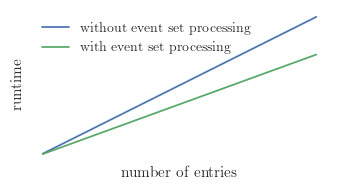

In [2]:
L = 1
C = 1
R = 1
W = 1

def intermediate_without(n_events, n_samples = 4, schema_size = 3):
    return (n_samples * (L + C)) + (n_events * (schema_size * R + (schema_size + 1) * W))

def analyse_without(n_events, n_samples = 4, schema_size = 3):
    return (n_samples * L) + (n_events * (schema_size + 1) * R)

def intermediate_with(n_events, n_samples = 4, schema_size = 3):
    return (n_samples * (L + C)) + (n_events * (3 * R + W))

def analyse_with(n_events, n_samples = 4, schema_size = 3):
    return (2 * n_samples * L) + (n_events * (schema_size + 1) * R)

cost_without = np.array([intermediate_without(n) + analyse_without(n) for n in [1e6, 1e7, 5e7, 1e8]])
cost_with = np.array([intermediate_with(n) + analyse_with(n) for n in [1e6, 1e7, 5e7, 1e8]])

fig, ax = plt.subplots(figsize=(3.5,2))
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime")

linestyles = ["solid", "dashed", "dotted", "solid"]
markers = ["", "s", "^", "o"]

ax.plot([1_000_000, 10_000_000, 50_000_000, 100_000_000],
        cost_without,
        linestyle="solid",
        linewidth=1.25
       )

ax.plot([1_000_000, 10_000_000, 50_000_000, 100_000_000],
        cost_with,
        linestyle="solid",
        linewidth=1.25
       )

ax.legend(["without event set processing", "with event set processing"])

fig.tight_layout()
fig.savefig("plots/cost_analysis.pdf", transparent=True)
fig.savefig("plots/cost_analysis.png", transparent=True)
fig.savefig("plots/cost_analysis.tex", format="pgf", transparent=True)